In [16]:
from typing import Literal, TypedDict
from langgraph.graph import END, START, StateGraph


In [18]:
ActivityLevel = Literal[
    "sedentary",
    "lightly_active",
    "moderately_active",
    "very_active",
    "extra_active",
]


class CalorieState(TypedDict, total=False):
    gender: Literal["male", "female"]
    weight: float
    height: float
    age: int
    activity_level: ActivityLevel
    bmr: float
    tdee: float


In [19]:
def calculate_bmr(state: CalorieState) -> CalorieState:
    gender = state["gender"].strip().lower()
    weight = state["weight"]
    height = state["height"]
    age = state["age"]

    if gender == "male":
        bmr = (10 * weight) + (6.25 * height) - (5 * age) + 5
    elif gender == "female":
        bmr = (10 * weight) + (6.25 * height) - (5 * age) - 161
    else:
        raise ValueError("gender must be 'male' or 'female'")

    return {"bmr": round(bmr, 2)}


def calculate_tdee(state: CalorieState) -> CalorieState:
    multipliers = {
        "sedentary": 1.2,
        "lightly_active": 1.375,
        "moderately_active": 1.55,
        "very_active": 1.725,
        "extra_active": 1.9,
    }

    activity_level = state["activity_level"].strip().lower()
    if activity_level not in multipliers:
        raise ValueError(
            "activity_level must be one of: sedentary, lightly_active, "
            "moderately_active, very_active, extra_active"
        )

    tdee = state["bmr"] * multipliers[activity_level]
    return {"tdee": round(tdee, 2)}


In [20]:
graph = StateGraph(CalorieState)

graph.add_node("calculate_bmr", calculate_bmr)
graph.add_node("calculate_tdee", calculate_tdee)

graph.add_edge(START, "calculate_bmr")
graph.add_edge("calculate_bmr", "calculate_tdee")
graph.add_edge("calculate_tdee", END)

workflow = graph.compile()


In [21]:
initial_state = {
    "gender": "female",
    "weight": 80,
    "height": 173,
    "age": 30,
    "activity_level": "lightly_active",
}


In [22]:
final_state=workflow.invoke(initial_state)

print(final_state)

{'gender': 'female', 'weight': 80, 'height': 173, 'age': 30, 'activity_level': 'lightly_active', 'bmr': 1570.25, 'tdee': 2159.09}


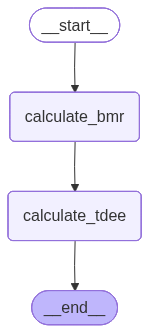

In [23]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())